In [29]:
%matplotlib inline

import os

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import skimage
import os
import seaborn as sns
import pandas as pd

import cv2

import sys
sys.path.append('../scripts/')

from BFmainlib import BF_image, HSV_threshold, HSV_transform

from Annotation_functions import draw_annotations, get_boxes, get_filtered_bboxes, morph_op

In [30]:
bacteria_names_list = ['../pictures/test_input_1.bmp','../pictures/test_input_2.bmp',
                       '../pictures/test_input_3.bmp','../pictures/test_input_5.bmp']

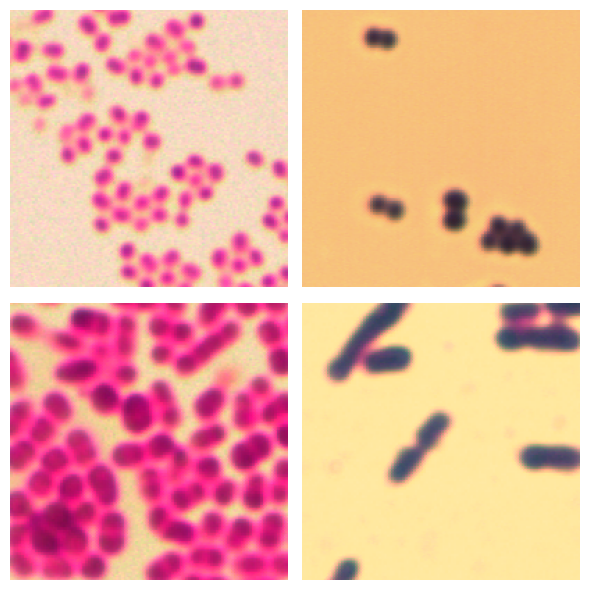

In [31]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    bacteria = cv2.imread(bacteria_names_list[i])
    axs[i//2][i%2].imshow(bacteria[700:900,1000:1200,::-1])
    axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

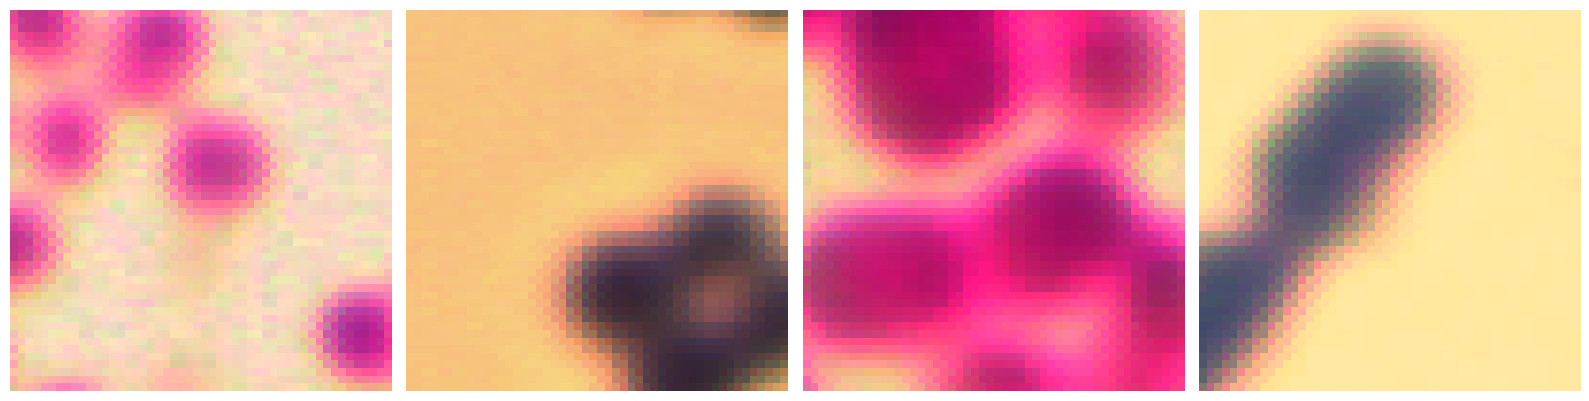

In [32]:
fig, axs = plt.subplots(1, 4, figsize = (16,16))
for i in range(4):
    bacteria = cv2.imread(bacteria_names_list[i])
    if i == 1:
        axs[i].imshow(bacteria[875:925,1100:1150,::-1])
        axs[i].axis('off')
    else:
        axs[i].imshow(bacteria[775:825,1075:1125,::-1])
        axs[i].axis('off')
fig.tight_layout()
plt.show()

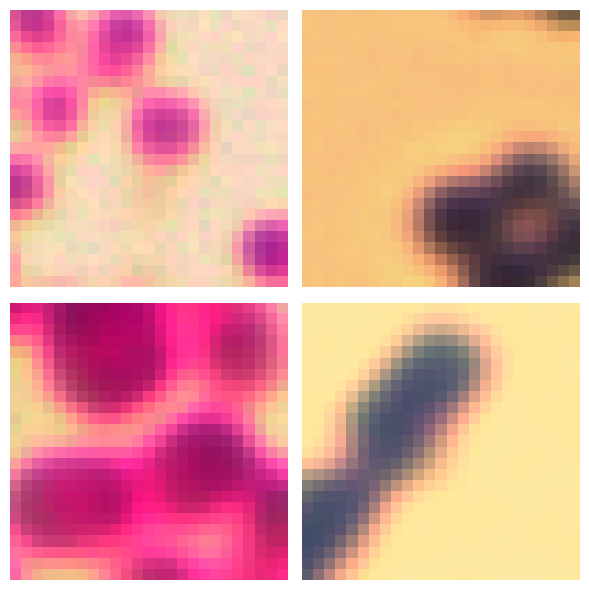

In [33]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    bacteria = cv2.imread(bacteria_names_list[i])
    bacteria_filtered = np.uint8(skimage.measure.block_reduce(bacteria, (2,2,1), np.mean, func_kwargs={'dtype': np.float16}))
    if i == 1:
        axs[i//2][i%2].imshow(bacteria_filtered[875//2:925//2,1100//2:1150//2,::-1])
        axs[i//2][i%2].axis('off')
    else:
        axs[i//2][i%2].imshow(bacteria_filtered[775//2:825//2,1075//2:1125//2,::-1])
        axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

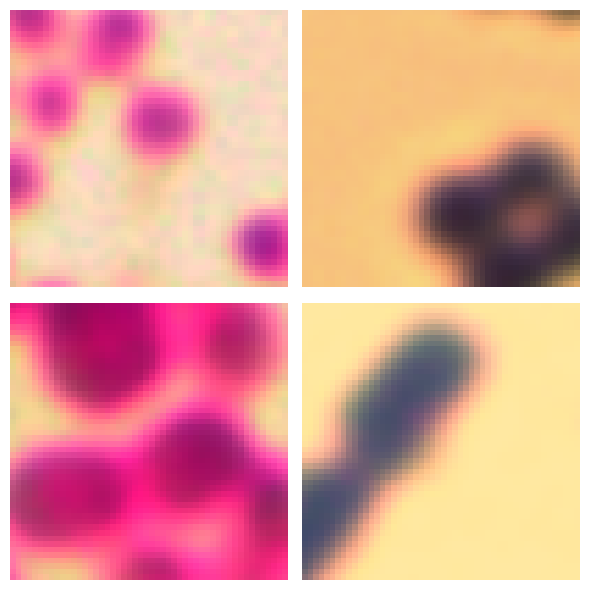

In [34]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    bacteria = cv2.imread(bacteria_names_list[i])
    bacteria_filtered = cv2.resize(np.uint8(skimage.measure.block_reduce(bacteria, (2,2,1), np.mean, func_kwargs={'dtype': np.float16})),
                                bacteria.shape[1::-1], interpolation = cv2.INTER_CUBIC)
    if i == 1:
        axs[i//2][i%2].imshow(bacteria_filtered[875:925,1100:1150,::-1])
        axs[i//2][i%2].axis('off')
    else:
        axs[i//2][i%2].imshow(bacteria_filtered[775:825,1075:1125,::-1])
        axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

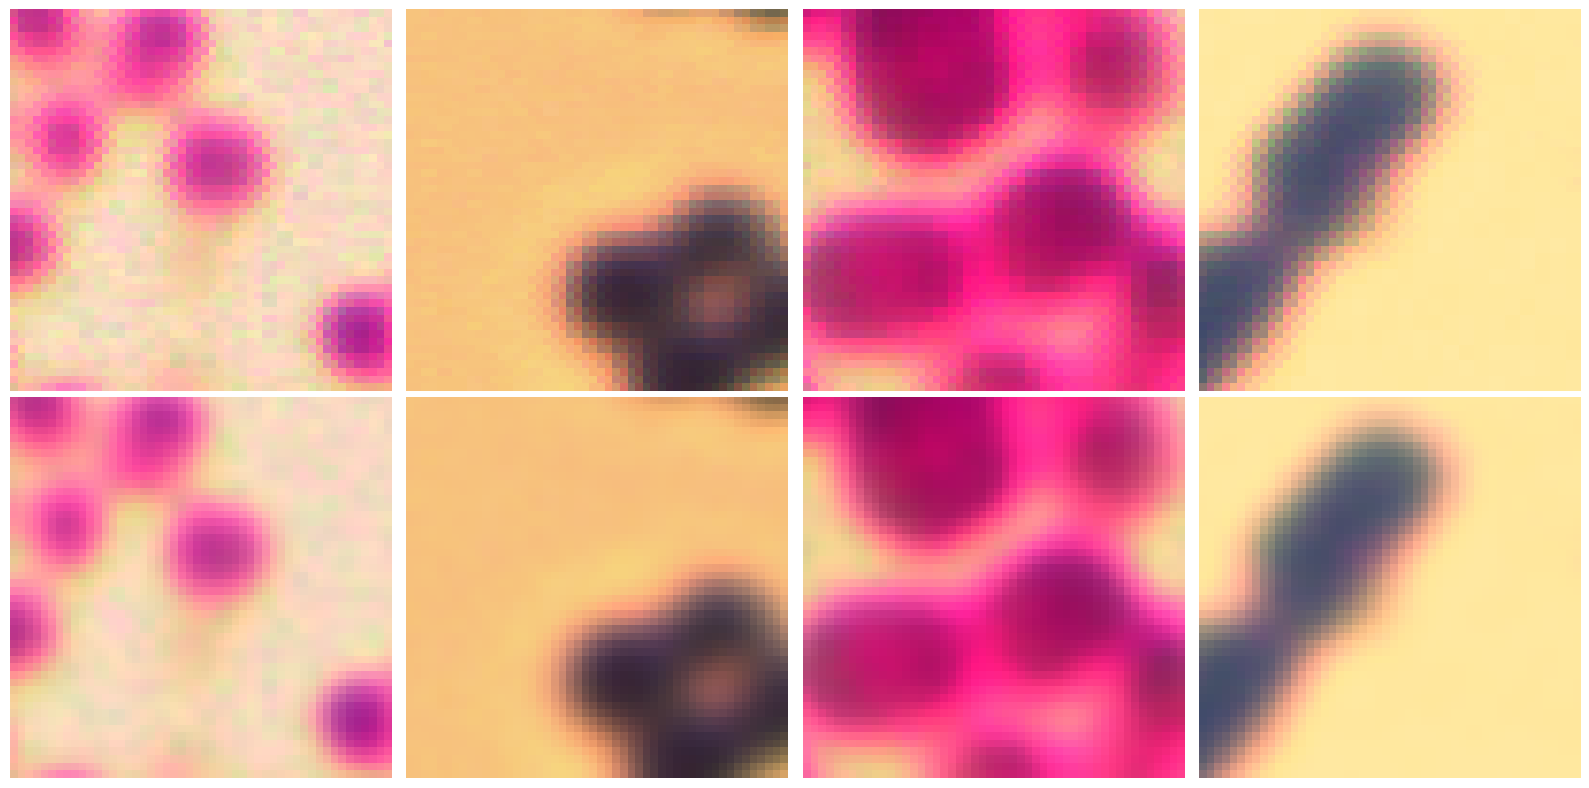

In [35]:
fig, axs = plt.subplots(2, 4, figsize = (16,8))
for i in range(8):
    bacteria = cv2.imread(bacteria_names_list[i%4])
    bacteria_filtered = cv2.resize(np.uint8(skimage.measure.block_reduce(bacteria, (2,2,1), np.mean, func_kwargs={'dtype': np.float16})),
                                bacteria.shape[1::-1], interpolation = cv2.INTER_CUBIC)
    if i <= 3:
        if i%4 == 1:
            axs[i//4][i%4].imshow(bacteria[875:925,1100:1150,::-1])
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(bacteria[775:825,1075:1125,::-1])
            axs[i//4][i%4].axis('off')
    else:
        if i%4 == 1:
            axs[i//4][i%4].imshow(bacteria_filtered[875:925,1100:1150,::-1])
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(bacteria_filtered[775:825,1075:1125,::-1])
            axs[i//4][i%4].axis('off')
fig.tight_layout()
plt.show()

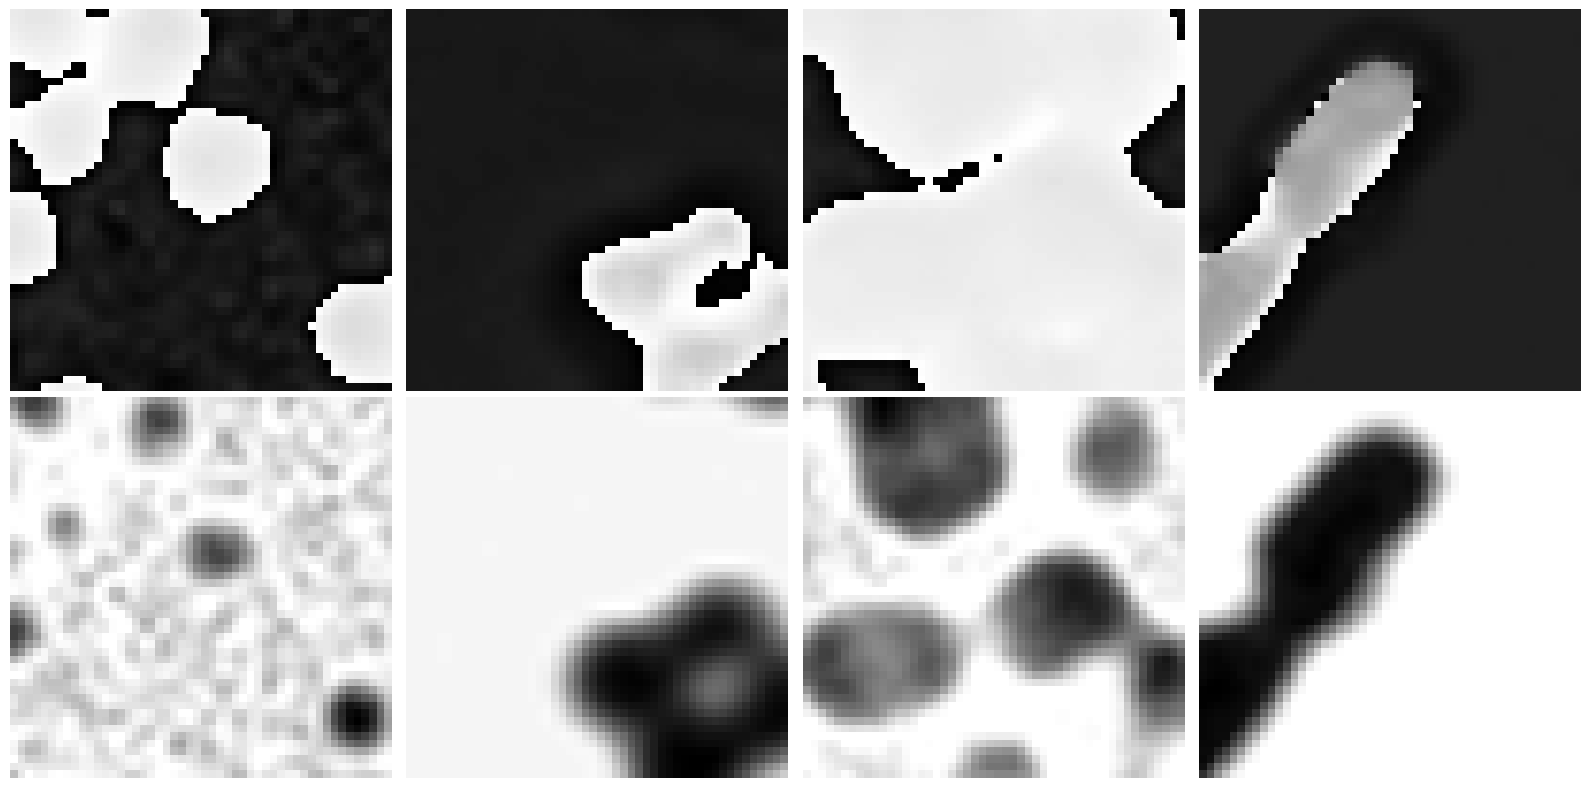

In [36]:
fig, axs = plt.subplots(2, 4, figsize = (16,8))
for i in range(8):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_names_list[i%4])
    test_image_class.preprocess_image()

    if i <= 3:
        if i%4 == 1:
            axs[i//4][i%4].imshow(HSV_transform(test_image_class.bacteria_image_preprocessed)[875:925,1100:1150,0],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(HSV_transform(test_image_class.bacteria_image_preprocessed)[775:825,1075:1125,0],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
    else:
        if i%4 == 1:
            axs[i//4][i%4].imshow(HSV_transform(test_image_class.bacteria_image_preprocessed)[875:925,1100:1150,2],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(HSV_transform(test_image_class.bacteria_image_preprocessed)[775:825,1075:1125,2],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
fig.tight_layout()
plt.show()

In [37]:
def detect_ridges(gray, sigma=2.0):
    i1, i2 = skimage.feature.hessian_matrix_eigvals(skimage.feature.hessian_matrix(gray, sigma, use_gaussian_derivatives=True))
    return i1, i2

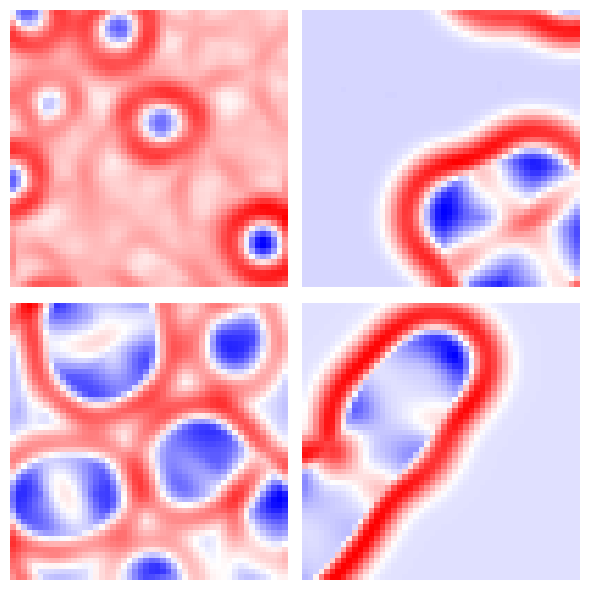

In [38]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_names_list[i%4])
    test_image_class.preprocess_image()
    if i == 1:
        axs[i//2][i%2].imshow(detect_ridges(skimage.util.invert(HSV_transform(test_image_class.bacteria_image_preprocessed)[:,:,2]), sigma=2.5)[0][875:925,1100:1150], cmap='bwr')
        axs[i//2][i%2].axis('off')
    else:
        axs[i//2][i%2].imshow(detect_ridges(skimage.util.invert(HSV_transform(test_image_class.bacteria_image_preprocessed)[:,:,2]), sigma=2.5)[0][775:825,1075:1125], cmap='bwr')
        axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

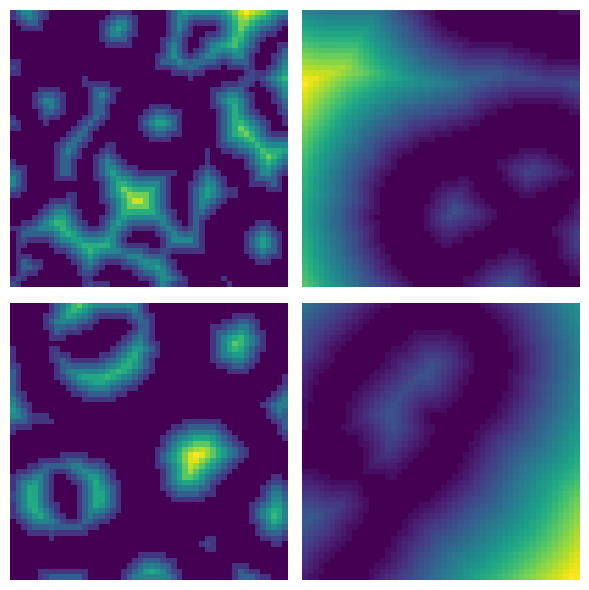

In [39]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_names_list[i%4])
    test_image_class.preprocess_image()


    image_hsv = HSV_transform(test_image_class.bacteria_image_preprocessed)
    image_hue_mask = HSV_threshold(image_hsv, type = 'simple_hue')
    image_value_mask = HSV_threshold(image_hsv, type = 'simple_value')

    image_ridges = detect_ridges(skimage.util.invert(HSV_transform(test_image_class.bacteria_image_preprocessed)[:,:,2]), sigma=2.5)[0]
    image_ridges_mean = np.mean(image_ridges)
    image_ridges_std = np.std(image_ridges)
    image_ridges_markers = cv2.threshold(image_ridges, image_ridges_mean + image_ridges_std/2, 1, cv2.THRESH_BINARY_INV)[1]

    image_watershed_mask = np.clip(image_value_mask + image_hue_mask, None, 1)

    coords = image_watershed_mask*image_ridges_markers
    markers, _ = sp.ndimage.label(coords)
    distance = sp.ndimage.distance_transform_edt(image_ridges_markers)
    

    if i == 1:
        axs[i//2][i%2].imshow(distance[875:925,1100:1150])
        axs[i//2][i%2].axis('off')
    else:
        axs[i//2][i%2].imshow(distance[775:825,1075:1125])
        axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

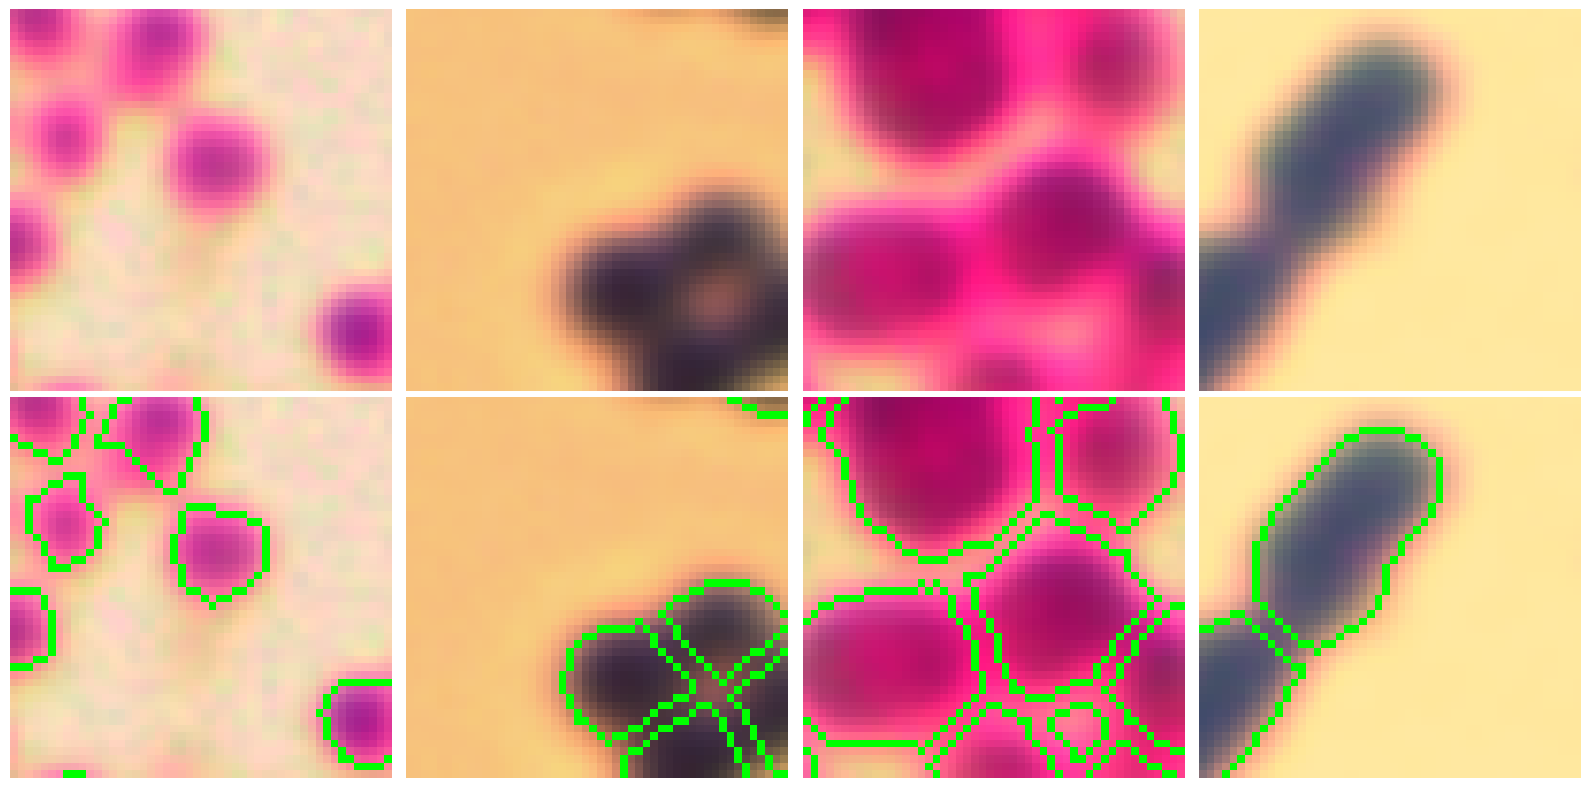

In [40]:
fig, axs = plt.subplots(2, 4, figsize = (16,8))
for i in range(8):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_names_list[i%4])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    if i <= 3:
        if i%4 == 1:
            axs[i//4][i%4].imshow(test_image_class.bacteria_image_preprocessed[875:925,1100:1150],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(test_image_class.bacteria_image_preprocessed[775:825,1075:1125],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
    else:
        if i%4 == 1:
            axs[i//4][i%4].imshow(test_image_class.segment_draw()[875:925,1100:1150],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
        else:
            axs[i//4][i%4].imshow(test_image_class.segment_draw()[775:825,1075:1125],
                                  cmap='gray')
            axs[i//4][i%4].axis('off')
fig.tight_layout()
plt.show()

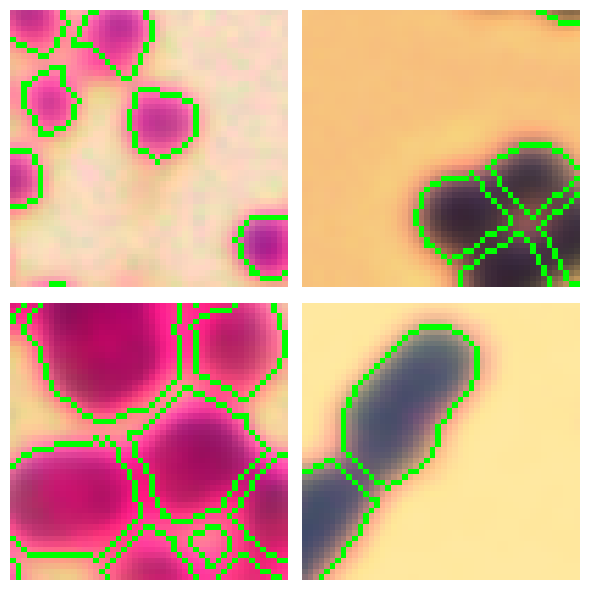

In [41]:
fig, axs = plt.subplots(2, 2, figsize = (6,6))
for i in range(4):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_names_list[i%4])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    if i == 1:
        axs[i//2][i%2].imshow(test_image_class.segment_draw()[875:925,1100:1150])
        axs[i//2][i%2].axis('off')
    else:
        axs[i//2][i%2].imshow(test_image_class.segment_draw()[775:825,1075:1125])
        axs[i//2][i%2].axis('off')
fig.tight_layout()
plt.show()

In [42]:
test_image_class = BF_image(verbose=False)
test_image_class.load_image(bacteria_names_list[i%4])
test_image_class.preprocess_image()
test_image_class.segment_image(type='ridges')
objects_features = test_image_class.all_object_features()
dataset = pd.DataFrame.from_dict([{'ID': key} | objects_features[key]['color_props'] | objects_features[key]['region_props']for key in objects_features], dtype=float)

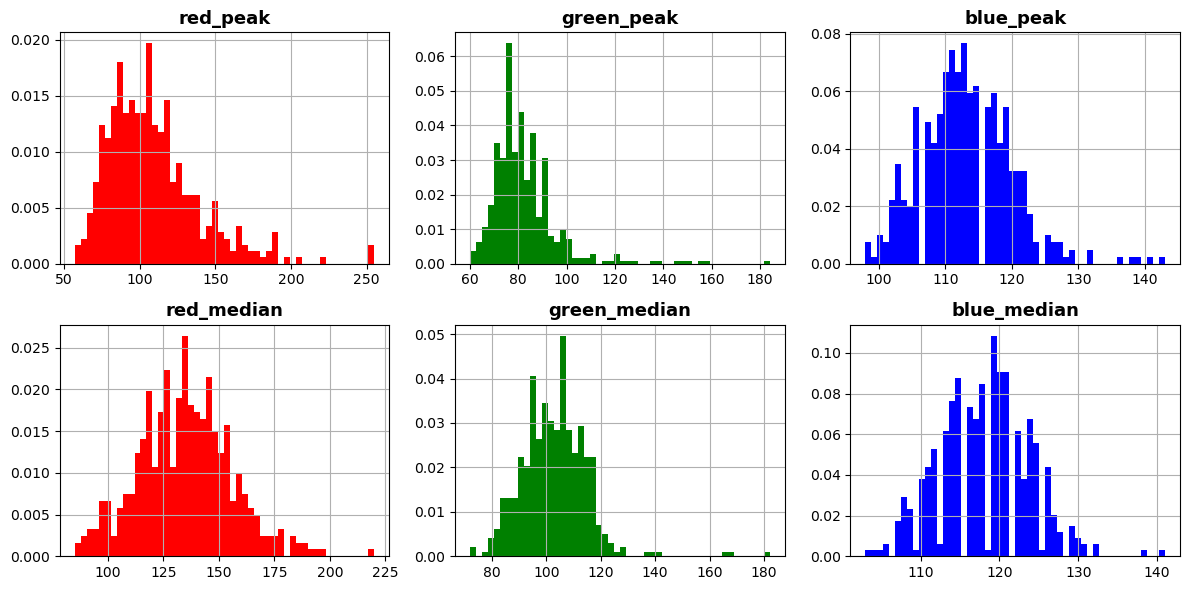

In [73]:
test_image_class = BF_image(verbose=False)
test_image_class.load_image(bacteria_names_list[3])
test_image_class.preprocess_image()
test_image_class.segment_image(type='ridges')
objects_features = test_image_class.all_object_features()
dataset = pd.DataFrame.from_dict([{'ID': key} | objects_features[key]['color_props'] | objects_features[key]['region_props']for key in objects_features], dtype=float)

dataset_column_names = {0:"red_peak", 1:"green_peak", 2:"blue_peak", 3:"red_median", 4:"green_median", 5:"blue_median"}
fig, axs = plt.subplots(2, 3, figsize = (12,6))
for i in range(6):
    if i%3 == 0:
        color = 'red'
    elif i%3 == 1:
        color = 'green'
    elif i%3 == 2:
        color = 'blue'
    axs[i//3][i%3].hist(dataset[dataset_column_names[i]], bins = 50, color=color)
    axs[i//3][i%3].set_title(dataset_column_names[i], fontweight="bold", size = 13)
    axs[i//3][i%3].grid()

fig.tight_layout()
plt.show()

In [56]:
dataset.columns

Index(['ID', 'red_peak', 'green_peak', 'blue_peak', 'red_median',
       'green_median', 'blue_median', 'perimeter', 'area', 'axis_major_length',
       'axis_minor_length', 'eccentricity', 'orientation'],
      dtype='object')

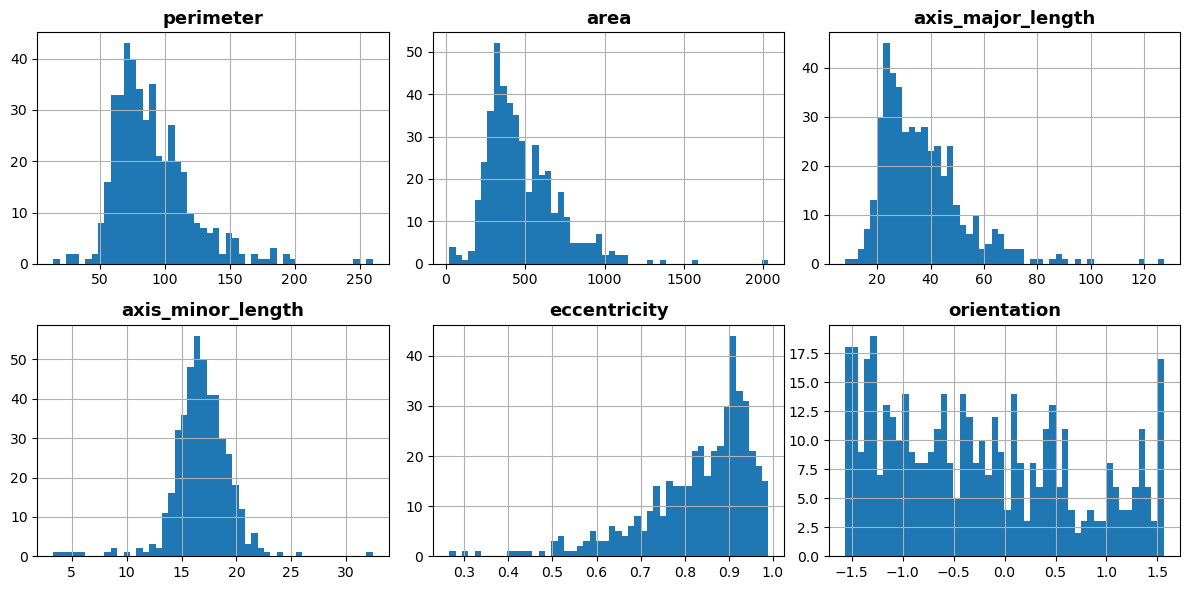

In [74]:
test_image_class = BF_image(verbose=False)
test_image_class.load_image(bacteria_names_list[3])
test_image_class.preprocess_image()
test_image_class.segment_image(type='ridges')
objects_features = test_image_class.all_object_features()
dataset = pd.DataFrame.from_dict([{'ID': key} | objects_features[key]['color_props'] | objects_features[key]['region_props']for key in objects_features], dtype=float)

dataset_column_names = {0:"perimeter", 1:"area", 2:"axis_major_length", 3:"axis_minor_length", 4:"eccentricity", 5:"orientation"}
fig, axs = plt.subplots(2, 3, figsize = (12,6))
for i in range(6):
    axs[i//3][i%3].hist(dataset[dataset_column_names[i]], bins = 50)
    axs[i//3][i%3].set_title(dataset_column_names[i], fontweight="bold", size = 13)
    axs[i//3][i%3].grid()

fig.tight_layout()
plt.show()

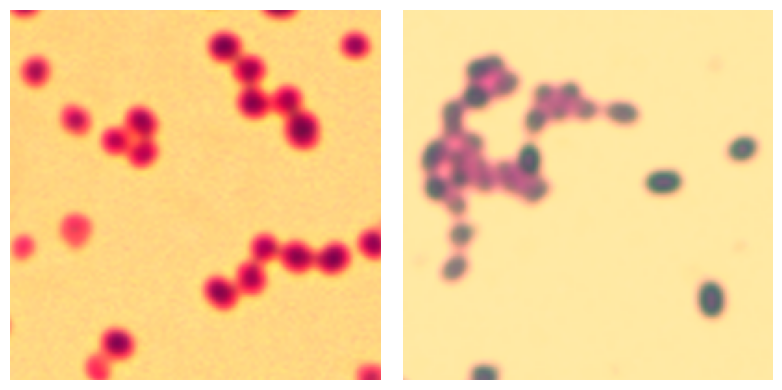

In [83]:
bacteria_class_names_list = ['../pictures/negative_coccus_example.bmp', '../pictures/positive_coccus_example.bmp']
fig, axs = plt.subplots(1, 2, figsize = (8,4))
for i in range(2):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(bacteria_class_names_list[i%2])
    test_image_class.preprocess_image()
    # test_image_class.segment_image(type='ridges')
    
    axs[i%2].imshow(test_image_class.bacteria_image_preprocessed[500:700,700:900])
    # axs[i%2].imshow(test_image_class.segment_draw()[500:700,700:900])
    axs[i%2].axis('off')
fig.tight_layout()
plt.show()